# Viz per Dataset

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS, TSNE
from sklearn.decomposition import PCA

In [2]:
# -----------------------------
# 1) LeRobot parquet / dataset dir 로드: joint(action 또는 observation.state)를 7D 포인트로
# -----------------------------
def resolve_pose_key(df: pd.DataFrame, key: str | None = None, preferred_keys=("observation.state", "action")):
    if key is not None:
        if key not in df.columns:
            raise KeyError(f"Column '{key}' not found. Available: {list(df.columns)[:20]} ...")
        return key

    for candidate in preferred_keys:
        if candidate in df.columns:
            return candidate

    raise KeyError(
        "No joint-like column found. Tried "
        f"{preferred_keys}, available columns: {list(df.columns)[:20]} ..."
    )


def _extract_pose_arrays(df: pd.DataFrame, key: str | None = None):
    key_used = resolve_pose_key(df, key=key)
    X = np.stack(df[key_used].to_numpy())
    episode = df["episode_index"].to_numpy() if "episode_index" in df.columns else None
    frame = df["frame_index"].to_numpy() if "frame_index" in df.columns else None
    ts = df["timestamp"].to_numpy() if "timestamp" in df.columns else None
    return df, X, episode, frame, ts, key_used


def load_points_from_dataset_dir(root_path: str | Path, key: str | None = None, parquet_glob="data/**/*.parquet"):
    root = Path(root_path)
    parquet_files = sorted(root.glob(parquet_glob))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found under: {root / 'data'}")

    dfs = []
    failed = []
    for pq in parquet_files:
        try:
            dfs.append(pd.read_parquet(pq))
        except Exception as e:
            failed.append((str(pq), str(e)))

    if not dfs:
        raise RuntimeError(f"All parquet reads failed under: {root}")

    df = pd.concat(dfs, axis=0, ignore_index=True)
    df, X, episode, frame, ts, key_used = _extract_pose_arrays(df, key=key)
    print(f"[load_points_from_dataset_dir] root={root} | key={key_used} | parquet_files={len(parquet_files)}")
    return df, X, episode, frame, ts


def load_points(source_path: str | Path, key: str | None = None):
    source_path = Path(source_path)
    if source_path.is_dir():
        return load_points_from_dataset_dir(source_path, key=key)

    df = pd.read_parquet(source_path)
    df, X, episode, frame, ts, key_used = _extract_pose_arrays(df, key=key)
    print(f"[load_points] file={source_path} | key={key_used}")
    return df, X, episode, frame, ts


def subsample(X, episode=None, frame=None, ts=None, n=5000, seed=0):
    N = X.shape[0]
    if n is None or N <= n:
        return X, episode, frame, ts, np.arange(N)

    rng = np.random.RandomState(seed)
    idx = rng.choice(N, n, replace=False)
    idx.sort()
    def pick(a): return a[idx] if a is not None else None
    return X[idx], pick(episode), pick(frame), pick(ts), idx


# -----------------------------
# 2) (추천) PCA 2D: 빠른 전역 구조 확인
# -----------------------------
def plot_pca(X, color=None, title="PCA (2D)"):
    Xs = StandardScaler().fit_transform(X)
    Z = PCA(n_components=2, random_state=0).fit_transform(Xs)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=4, c=color)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) (거리 보존에 더 직접적) MDS 2D: distance 기반 시각화
# -----------------------------
def plot_mds(X, color=None, title="MDS (2D) - distance-preserving", max_points=2000):
    # MDS는 O(N^2)라 너무 크면 느림 -> 2000 정도로 자르는 게 보통
    X2, color2, _, _, _ = subsample(X, episode=color, n=max_points)

    Xs = StandardScaler().fit_transform(X2)
    D = pairwise_distances(Xs, metric="euclidean")

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=0,
        normalized_stress="auto",
    )
    Z = mds.fit_transform(D)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=6, c=color2)
    plt.title(f"{title} (N={Xs.shape[0]})")
    plt.xlabel("dim1"); plt.ylabel("dim2")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) t-SNE 2D: 이웃 구조/군집 보기 좋음 (거리 해석은 '국소' 위주)
# -----------------------------
def plot_tsne(X, color=None, title="t-SNE (2D)", max_points=5000, perplexity=30, max_iter=1000):
    X2, color2, _, _, _ = subsample(X, episode=color, n=max_points)

    Xs = StandardScaler().fit_transform(X2)
    tsne = TSNE(
        n_components=2,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        max_iter=max_iter,
        random_state=0,
    )
    Z = tsne.fit_transform(Xs)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=4, c=color2)
    plt.title(f"{title} (N={Xs.shape[0]}, perplexity={perplexity})")
    plt.xlabel("dim1"); plt.ylabel("dim2")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 5) UMAP 2D: 국소+전역 밸런스 좋고 빠름 (설치 필요)
# -----------------------------
def plot_umap(X, color=None, title="UMAP (2D)", max_points=20000, n_neighbors=30, min_dist=0.1):
    import umap  # pip install umap-learn

    X2, color2, _, _, _ = subsample(X, episode=color, n=max_points)

    Xs = StandardScaler().fit_transform(X2)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=0,
    )
    Z = reducer.fit_transform(Xs)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=3, c=color2)
    plt.title(f"{title} (N={Xs.shape[0]}, n_neighbors={n_neighbors}, min_dist={min_dist})")
    plt.xlabel("dim1"); plt.ylabel("dim2")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 6) (진짜 거리 확인) 샘플 일부의 pairwise distance heatmap
# -----------------------------
def plot_distance_heatmap(X, title="Pairwise distance heatmap", max_points=300, metric="euclidean"):
    X2, _, _, _, _ = subsample(X, n=max_points)
    Xs = StandardScaler().fit_transform(X2)
    D = pairwise_distances(Xs, metric=metric)

    plt.figure(figsize=(6.5, 5.5))
    plt.imshow(D, interpolation="nearest")
    plt.colorbar()
    plt.title(f"{title} (N={Xs.shape[0]})")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 7) "특정 pose" 기준으로 거리 분포 보기
# -----------------------------
def plot_distance_to_reference(X, ref_index=0, title="Distance to reference pose"):
    Xs = StandardScaler().fit_transform(X)
    ref = Xs[ref_index:ref_index+1]
    d = pairwise_distances(Xs, ref).ravel()

    plt.figure(figsize=(6.5, 4.5))
    plt.hist(d, bins=80)
    plt.title(f"{title} (ref_index={ref_index})")
    plt.xlabel("distance"); plt.ylabel("count")
    plt.tight_layout()
    plt.show()


### test1

[load_points_from_dataset_dir] root=/nas/Dataset/VLA/UON/Isaacsim/OMY_apple_picking/auto_fixed_place_ALL | key=observation.state | parquet_files=1
X: (93525, 7) episodes: 393 key: observation.state


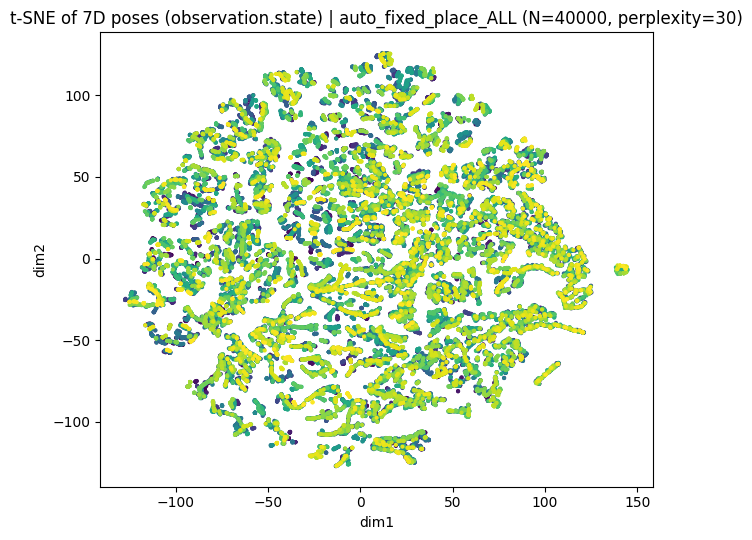

/home/uon/ochansol/lerobot/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


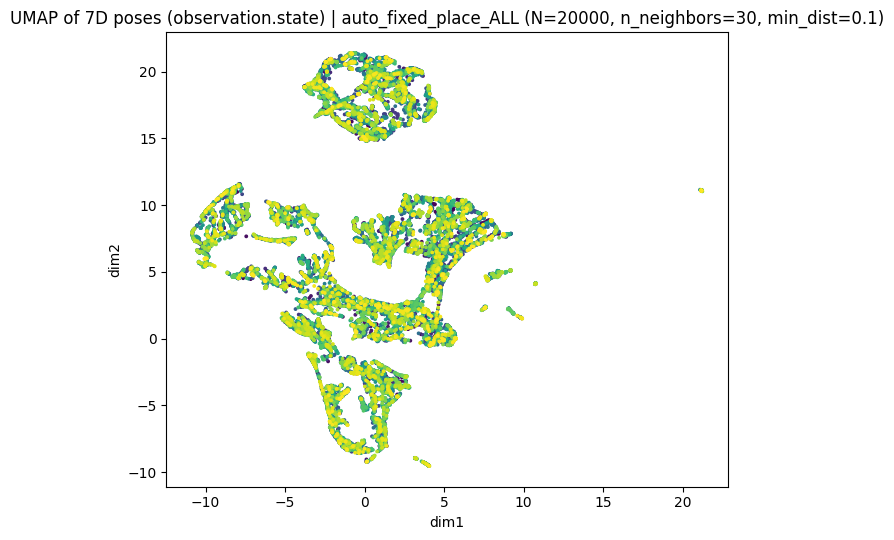

In [3]:
root_path = "/nas/Dataset/VLA/UON/Isaacsim/OMY_apple_picking/auto_fixed_place_ALL"
key = None  # None이면 observation.state -> action 순으로 자동 선택

df, X, episode, frame, ts = load_points(root_path, key=key)
key_used = resolve_pose_key(df, key=key)
print("X:", X.shape, "episodes:", len(np.unique(episode)) if episode is not None else None, "key:", key_used)

color = episode  # episode별로 색 보고 싶으면

# 0) 전역 구조(빠름)
# plot_pca(X, color=color, title=f"PCA of 7D poses ({key_used})")

# 1) '거리 보존' 관점 (추천)
# plot_mds(X, color=color, title=f"MDS of 7D poses ({key_used})", max_points=2000)

# 2) 군집/모드(국소 구조) 보기
plot_tsne(X, color=color, title=f"t-SNE of 7D poses ({key_used}) | {Path(root_path).name}", max_points=40000, perplexity=30)

# 3) UMAP (있으면 추천)
plot_umap(X, color=color, title=f"UMAP of 7D poses ({key_used}) | {Path(root_path).name}")

# 4) 거리행렬을 직접 보기(샘플 일부)
# plot_distance_heatmap(X, title=f"Distance heatmap ({key_used})", max_points=300)

# 5) 특정 pose(예: index 0) 기준 거리 분포
# plot_distance_to_reference(X, ref_index=5, title=f"Distance to ref pose ({key_used})")


X: (50901, 14) episodes: 81


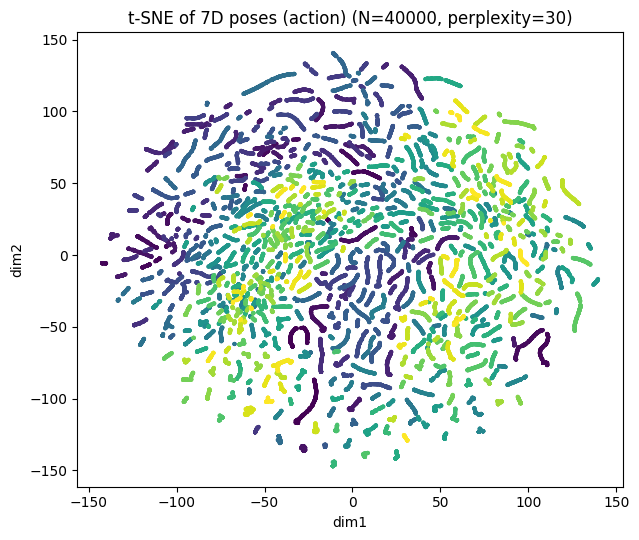

/home/uon/ochansol/lerobot/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


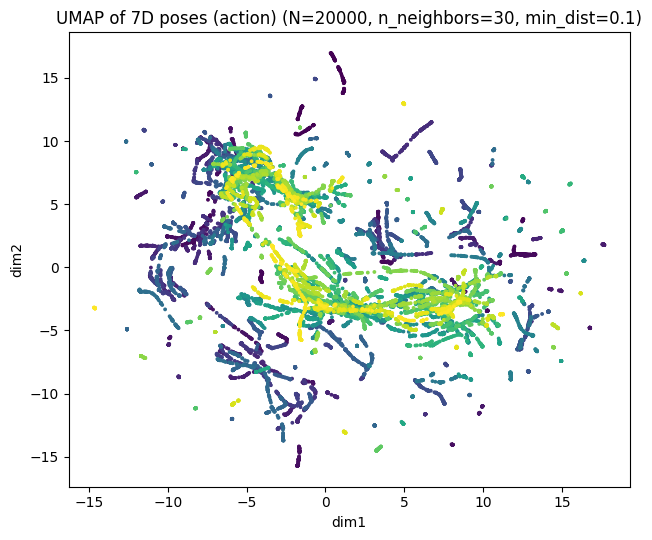

In [ ]:

root_path  = "/nas/Dataset/VLA/UON/repo_dualarm2"
parquet_path = f"{root_path}/data/chunk-000/file-000.parquet"  # <- 여기만 바꿔
key = "action"  # 또는 "observation.state"

df, X, episode, frame, ts = load_points(parquet_path, key=key)
print("X:", X.shape, "episodes:", len(np.unique(episode)) if episode is not None else None)

color = episode  # episode별로 색 보고 싶으면

# 0) 전역 구조(빠름)
# plot_pca(X, color=color, title=f"PCA of 7D poses ({key})")

# 1) '거리 보존' 관점 (추천)
# plot_mds(X, color=color, title=f"MDS of 7D poses ({key})", max_points=2000)

# 2) 군집/모드(국소 구조) 보기
plot_tsne(X, color=color, title=f"t-SNE of 7D poses ({key})", max_points=40000, perplexity=30)

# 3) UMAP (있으면 추천)
plot_umap(X, color=color, title=f"UMAP of 7D poses ({key})")

# 4) 거리행렬을 직접 보기(샘플 일부)
# plot_distance_heatmap(X, title=f"Distance heatmap ({key})", max_points=300)

# 5) 특정 pose(예: index 0) 기준 거리 분포
# plot_distance_to_reference(X, ref_index=5, title=f"Distance to ref pose ({key})")



omy_f3m_test2
  -> failed to load parquet
omy_f3m_test_pnp
  -> failed to load parquet
omy_f3m_test_traj_perform
  -> failed to load parquet
omy_f3m_test2_v30
X: (48927, 7) episodes: 100


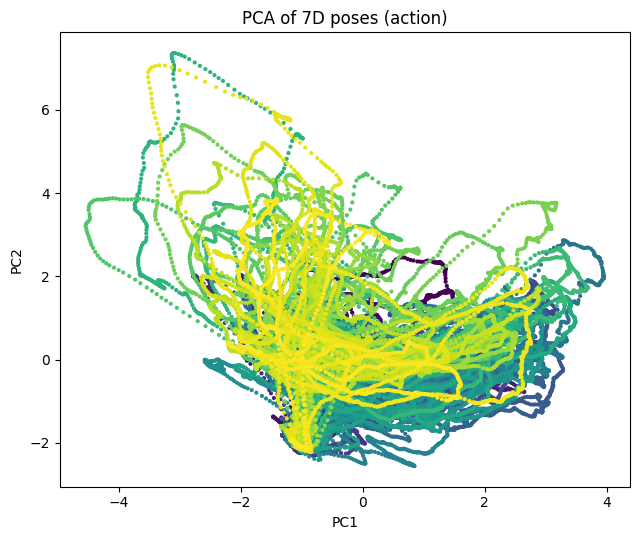

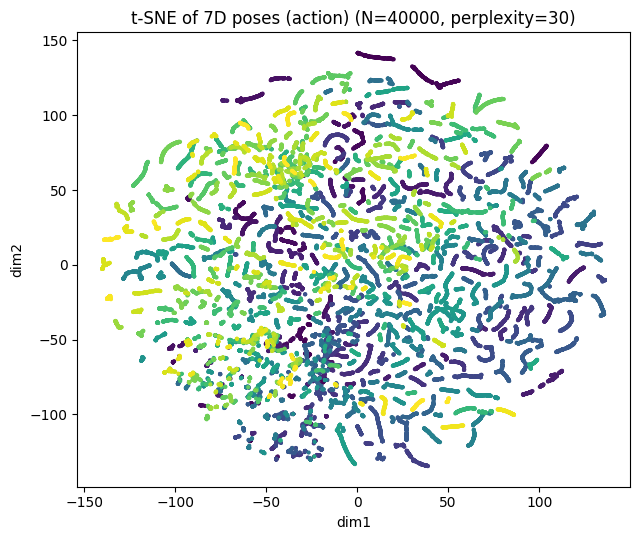

/home/uon/ochansol/lerobot/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


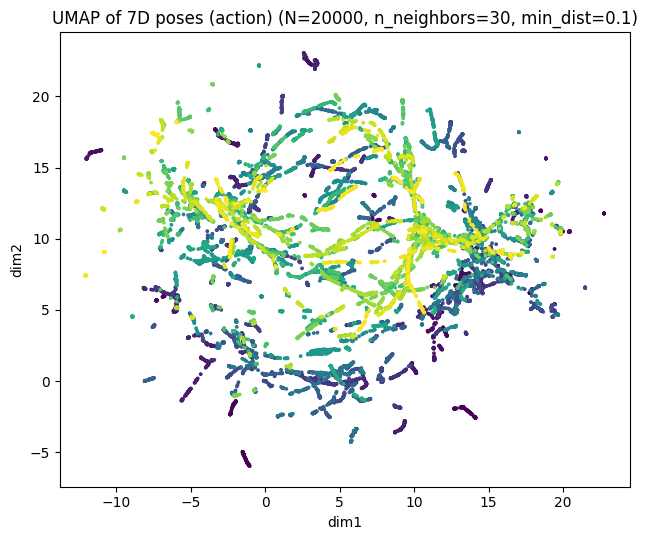

omy_f3m_test_traj_perform_v30
X: (12981, 7) episodes: 40


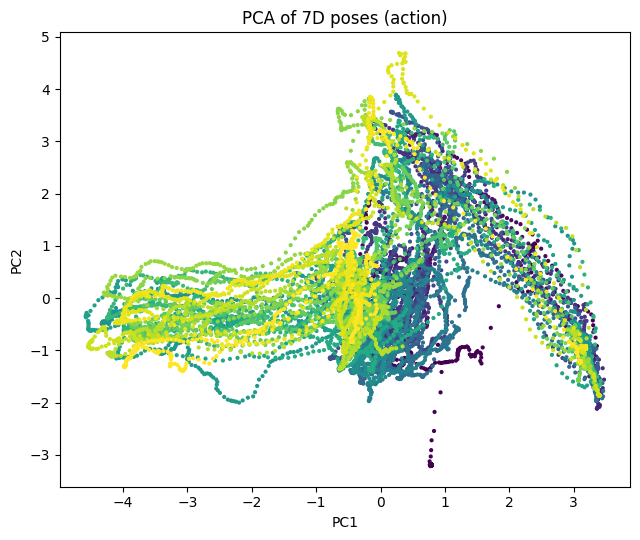

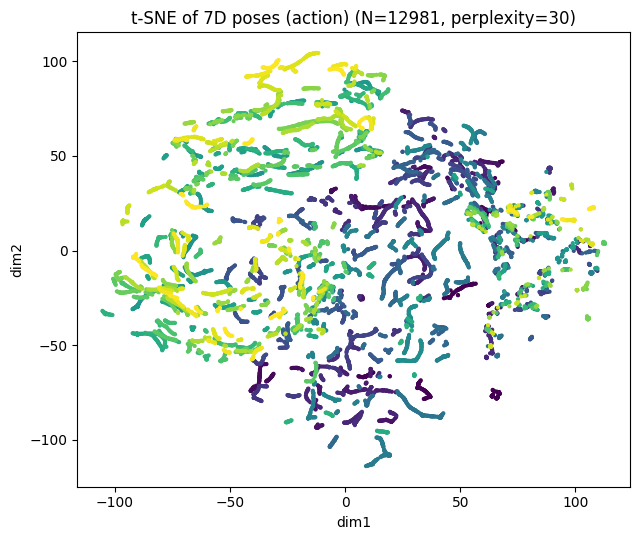

/home/uon/ochansol/lerobot/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


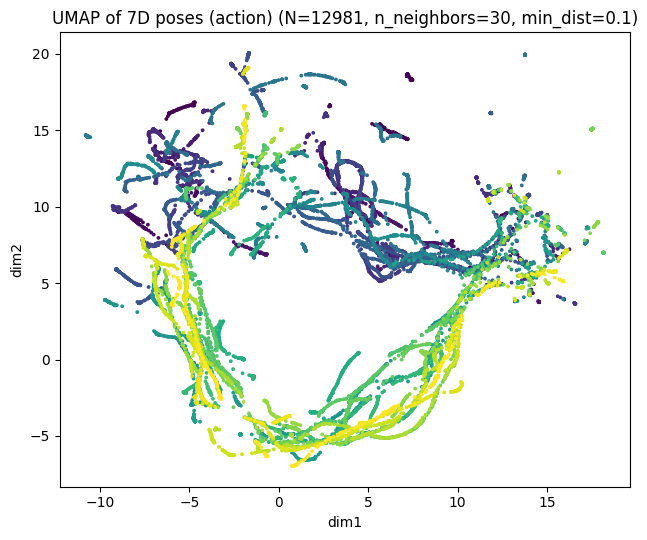

omy_f3m_202601-1
X: (16932, 7) episodes: 35


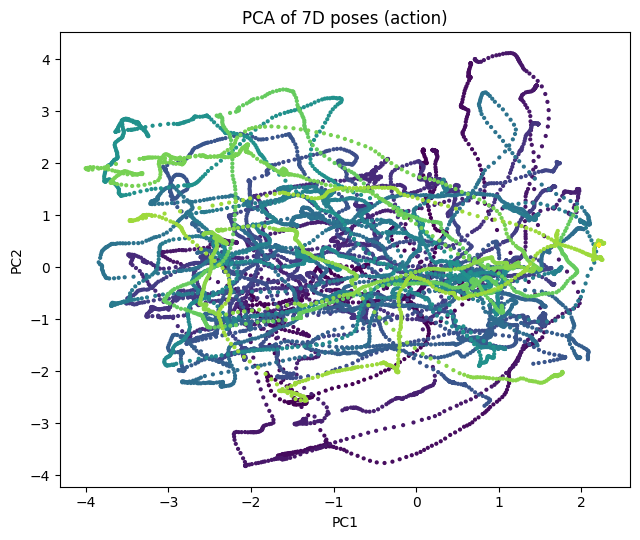

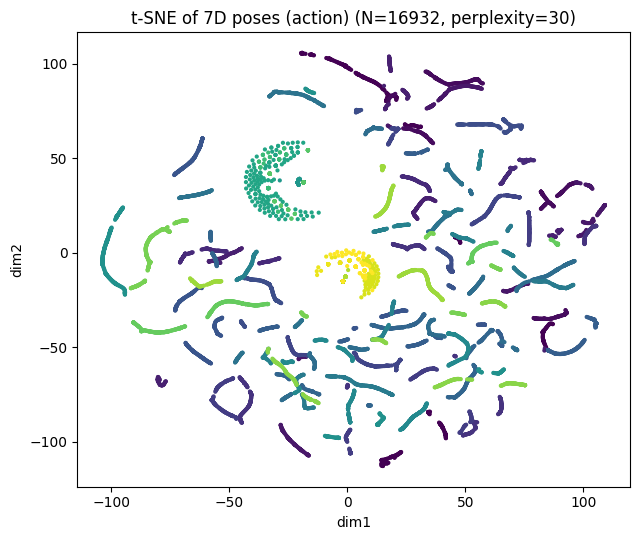

/home/uon/ochansol/lerobot/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


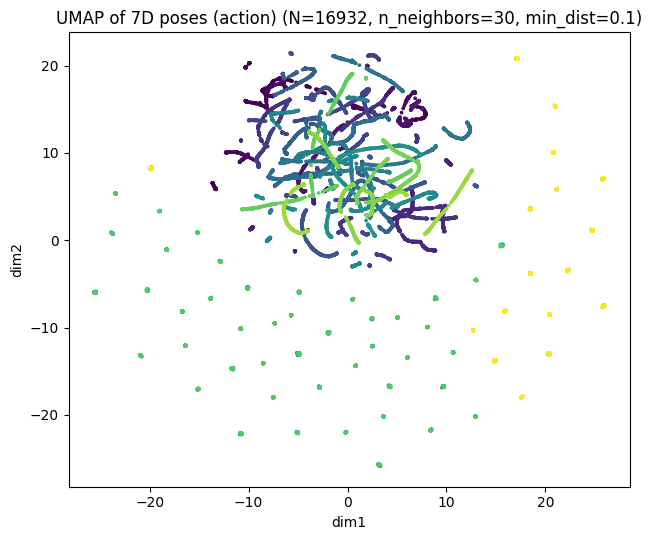

In [ ]:
import os
root_path = "/nas/etc/ACT_dataset_tmp"
dir_list = [ i for i in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, i)) ]
for dir_name in dir_list:
    print(dir_name)
    parquet_path = os.path.join(root_path, dir_name, "data/chunk-000/file-000.parquet")
    key = "action"  # 또는 "observation.state"
    try:
        df, X, episode, frame, ts = load_points(parquet_path, key=key)
    except:
        print("  -> failed to load parquet")
        continue
    print("X:", X.shape, "episodes:", len(np.unique(episode)) if episode is not None else None)

    color = episode  
    plot_pca(X, color=color, title=f"PCA of 7D poses ({key})")
    plot_tsne(X, color=color, title=f"t-SNE of 7D poses ({key})", max_points=40000, perplexity=30)
    plot_umap(X, color=color, title=f"UMAP of 7D poses ({key})")


# Viz Compare Datasets

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [16]:
# -----------------------------
# 1) LeRobot root dir 또는 parquet에서 7D pose 로드
# -----------------------------
def load_pose_points(source_path: str | Path, key: str | None = None):
    df, X, _, _, _ = load_points(source_path, key=key)
    key_used = resolve_pose_key(df, key=key)
    return X, key_used


# -----------------------------
# 2) 여러 데이터셋 로드 + 균등 샘플링
# -----------------------------
def load_multi_datasets(datasets: list[tuple[str, str | Path]],
                        key: str | None = None,
                        per_dataset_samples: int | None = 5000,
                        seed: int = 0):
    # datasets: [("dataset_name", "/path/to/lerobot_root_or_file"), ...]
    # return:
    #   X_all: (N_total, 7)
    #   y_all: (N_total,) int labels
    #   names: list[str] label names
    rng = np.random.RandomState(seed)

    X_list = []
    y_list = []
    names = []

    for label_id, (name, path) in enumerate(datasets):
        X, key_used = load_pose_points(path, key=key)
        n = X.shape[0]

        if per_dataset_samples is not None and n > per_dataset_samples:
            idx = rng.choice(n, per_dataset_samples, replace=False)
            X = X[idx]

        X_list.append(X)
        y_list.append(np.full((X.shape[0],), label_id, dtype=np.int32))
        names.append(name)

        print(f"[{label_id}] {name}: key={key_used}, loaded {n} rows -> used {X.shape[0]} samples")

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    return X_all, y_all, names


# -----------------------------
# 3) 공통 플롯 함수 (label별 색)
# -----------------------------
def plot_2d(Z, y, names, title):
    plt.figure(figsize=(7, 6))
    for label_id, name in enumerate(names):
        mask = (y == label_id)
        plt.scatter(Z[mask, 0], Z[mask, 1], s=4, label=name)
    plt.title(title)
    plt.xlabel("dim1")
    plt.ylabel("dim2")
    plt.legend(markerscale=3, fontsize=9)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) PCA / t-SNE 실행
# -----------------------------
def run_pca_tsne(X_all, y_all, names,
                 tsne_perplexity=30,
                 tsne_max_iter=1000,
                 tsne_init="pca"):
    # (중요) 서로 다른 데이터셋 비교니까 반드시 같은 스케일로 표준화
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_all)

    # PCA
    pca = PCA(n_components=2, random_state=0)
    Z_pca = pca.fit_transform(Xs)
    plot_2d(Z_pca, y_all, names, title=f"PCA (2D) | explained={pca.explained_variance_ratio_.sum():.3f}")

    # t-SNE (주의: 느리면 per_dataset_samples 줄여)
    tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init=tsne_init,
        learning_rate="auto",
        max_iter=tsne_max_iter,
        random_state=0,
    )
    Z_tsne = tsne.fit_transform(Xs)
    plot_2d(Z_tsne, y_all, names, title=f"t-SNE (2D) | perplexity={tsne_perplexity} | N={Xs.shape[0]}")


In [ ]:
datasets = [
    ("dataset_A", "/nas/etc/ACT_dataset_tmp/omy_f3m_test2_v30"),
    ("dataset_B", "/nas/Dataset/VLA/UON/Isaacsim_OMY"),
    # ("dataset_C", "/nas/Dataset/VLA/UON/repo_dualarm2"),
]

key = None  # None이면 observation.state -> action 순으로 자동 선택

# 공정 비교를 위해 각 데이터셋에서 동일 개수 샘플링 추천
X_all, y_all, names = load_multi_datasets(
    datasets,
    key=key,
    per_dataset_samples=40000,  # 너무 느리면 2000~5000 추천
    seed=0
)

run_pca_tsne(
    X_all, y_all, names,
    tsne_perplexity=30,
    tsne_max_iter=1000
)


# viz Pose in TSNE

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS, TSNE
from sklearn.decomposition import PCA

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS, TSNE
from sklearn.decomposition import PCA


def resolve_pose_key(df: pd.DataFrame, key: str | None = None, preferred_keys=("observation.state", "action")):
    if key is not None:
        if key not in df.columns:
            raise KeyError(f"Column '{key}' not found. Available: {list(df.columns)[:20]} ...")
        return key

    for candidate in preferred_keys:
        if candidate in df.columns:
            return candidate

    raise KeyError(
        "No joint-like column found. Tried "
        f"{preferred_keys}, available columns: {list(df.columns)[:20]} ..."
    )


def _extract_pose_arrays(df: pd.DataFrame, key: str | None = None):
    key_used = resolve_pose_key(df, key=key)
    X = np.stack(df[key_used].to_numpy())
    episode = df["episode_index"].to_numpy() if "episode_index" in df.columns else None
    frame = df["frame_index"].to_numpy() if "frame_index" in df.columns else None
    ts = df["timestamp"].to_numpy() if "timestamp" in df.columns else None
    return df, X, episode, frame, ts, key_used


def load_points_from_dataset_dir(root_path: str | Path, key: str | None = None, parquet_glob="data/**/*.parquet"):
    root = Path(root_path)
    parquet_files = sorted(root.glob(parquet_glob))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found under: {root / 'data'}")

    dfs = []
    failed = []
    for pq in parquet_files:
        try:
            dfs.append(pd.read_parquet(pq))
        except Exception as e:
            failed.append((str(pq), str(e)))

    if not dfs:
        raise RuntimeError(f"All parquet reads failed under: {root}")

    df = pd.concat(dfs, axis=0, ignore_index=True)
    df, X, episode, frame, ts, key_used = _extract_pose_arrays(df, key=key)
    print(f"[load_points_from_dataset_dir] root={root} | key={key_used} | parquet_files={len(parquet_files)}")
    return df, X, episode, frame, ts


def load_points(source_path: str | Path, key: str | None = None):
    source_path = Path(source_path)
    if source_path.is_dir():
        return load_points_from_dataset_dir(source_path, key=key)

    df = pd.read_parquet(source_path)
    df, X, episode, frame, ts, key_used = _extract_pose_arrays(df, key=key)
    print(f"[load_points] file={source_path} | key={key_used}")
    return df, X, episode, frame, ts


def subsample(X, episode=None, frame=None, ts=None, n=5000, seed=0):
    N = X.shape[0]
    if n is None or N <= n:
        return X, episode, frame, ts, np.arange(N)

    rng = np.random.RandomState(seed)
    idx = rng.choice(N, n, replace=False)
    idx.sort()
    def pick(a): return a[idx] if a is not None else None
    return X[idx], pick(episode), pick(frame), pick(ts), idx


def plot_pca(X, color=None, title="PCA (2D)"):
    Xs = StandardScaler().fit_transform(X)
    Z = PCA(n_components=2, random_state=0).fit_transform(Xs)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=4, c=color)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


def plot_tsne(X, color=None, title="t-SNE (2D)", max_points=5000, perplexity=30, max_iter=1000):
    X2, color2, _, _, _ = subsample(X, episode=color, n=max_points)

    Xs = StandardScaler().fit_transform(X2)
    tsne = TSNE(
        n_components=2,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        max_iter=max_iter,
        random_state=0,
    )
    Z = tsne.fit_transform(Xs)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=4, c=color2)
    plt.title(f"{title} (N={Xs.shape[0]}, perplexity={perplexity})")
    plt.xlabel("dim1"); plt.ylabel("dim2")
    plt.tight_layout()
    plt.show()


def plot_umap(X, color=None, title="UMAP (2D)", max_points=20000, n_neighbors=30, min_dist=0.1):
    import umap  # pip install umap-learn

    X2, color2, _, _, _ = subsample(X, episode=color, n=max_points)

    Xs = StandardScaler().fit_transform(X2)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=0,
    )
    Z = reducer.fit_transform(Xs)

    plt.figure(figsize=(6.5, 5.5))
    plt.scatter(Z[:, 0], Z[:, 1], s=3, c=color2)
    plt.title(f"{title} (N={Xs.shape[0]}, n_neighbors={n_neighbors}, min_dist={min_dist})")
    plt.xlabel("dim1"); plt.ylabel("dim2")
    plt.tight_layout()
    plt.show()


In [ ]:
root_path = "/nas/Dataset/VLA/UON/Isaacsim_OMY"
key = None  # None이면 observation.state -> action 순으로 자동 선택

df, X, episode, frame, ts = load_points(root_path, key=key)
key_used = resolve_pose_key(df, key=key)
print("X:", X.shape, "episodes:", len(np.unique(episode)) if episode is not None else None, "key:", key_used)

color = episode  # episode별로 색 보고 싶으면

# 0) 전역 구조(빠름)
plot_pca(X, color=color, title=f"PCA of 7D poses ({key_used}) | {Path(root_path).name}")

# 2) 군집/모드(국소 구조) 보기
plot_tsne(X, color=color, title=f"t-SNE of 7D poses ({key_used}) | {Path(root_path).name}", max_points=40000, perplexity=30)


# plot_umap(X, color=color, title=f"UMAP of 7D poses ({key_used}) | {Path(root_path).name}")


# Compare 2

In [ ]:
dir_path = [
    "/nas/Dataset/VLA/UON/Isaacsim_OMY",
    "/nas/Dataset/VLA/UON/Isaacsim_OMY_apple_picking",
    "/nas/Dataset/VLA/UON/omy_f3m_demo_apple_pepper_1+2",
]


key = None  # None이면 observation.state -> action 순으로 자동 선택
for root_path in dir_path:
    df, X, episode, frame, ts = load_points_from_dataset_dir(root_path, key=key)
    key_used = resolve_pose_key(df, key=key)
    parquet_files = sorted(Path(root_path).glob("data/**/*.parquet"))

    print(f"[{root_path}]")
    print(f"  merged parquet files: {len(parquet_files)}")
    print(f"  merged rows: {len(df)}")
    print("X:", X.shape, "episodes:", len(np.unique(episode)) if episode is not None else None, "key:", key_used)

    color = episode
    plot_tsne(X, color=color, title=f"t-SNE of 7D poses ({key_used}) | {Path(root_path).name}", max_points=40000, perplexity=30)
    plot_umap(X, color=color, title=f"UMAP of 7D poses ({key_used}) | {Path(root_path).name}")
